# Bitcoin Price. Prediction by ARIMA

In [15]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
import statsmodels.api as sm
import warnings
from itertools import product
from datetime import datetime
warnings.filterwarnings('ignore')
plt.style.use('seaborn-poster')

## Data Exploration

In [ ]:
# Load data
df = pd.read_csv('../../data/bitcoin_price_prediction/btcusd_1-min_data.csv')

# Derive Weighted_Price as (High + Low + Close) / 3 (VWAP approximation)
# Original dataset had a Weighted_Price column; substitute dataset does not
if 'Weighted_Price' not in df.columns:
    df['Weighted_Price'] = (df['High'] + df['Low'] + df['Close']) / 3

# Validation
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
df.head()

,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
0,1325317920,4.39,4.39,4.39,4.39,0.455581,2.0,4.39
1,1325317980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1325318040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1325318100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1325318160,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# Unix-time to 
df.Timestamp = pd.to_datetime(df.Timestamp, unit='s')

# Resampling to daily frequency
df.index = df.Timestamp
df = df.resample('D').mean()

# Resampling to monthly frequency
df_month = df.resample('M').mean()

# Resampling to annual frequency
df_year = df.resample('A-DEC').mean()

# Resampling to quarterly frequency
df_Q = df.resample('Q-DEC').mean()

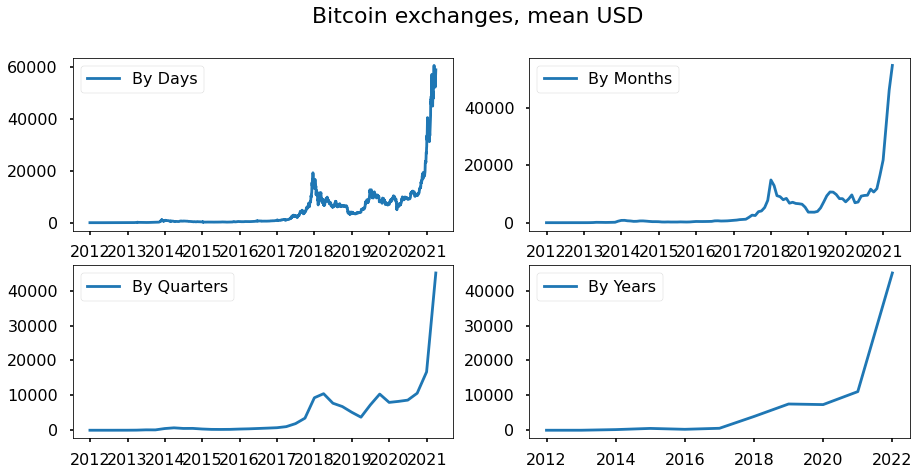

In [18]:
# PLOTS
fig = plt.figure(figsize=[15, 7])
plt.suptitle('Bitcoin exchanges, mean USD', fontsize=22)

plt.subplot(221)
plt.plot(df.Weighted_Price, '-', label='By Days')
plt.legend()

plt.subplot(222)
plt.plot(df_month.Weighted_Price, '-', label='By Months')
plt.legend()

plt.subplot(223)
plt.plot(df_Q.Weighted_Price, '-', label='By Quarters')
plt.legend()

plt.subplot(224)
plt.plot(df_year.Weighted_Price, '-', label='By Years')
plt.legend()

# plt.tight_layout()
plt.show()

I will predict bitcoin prices by months.

## Stationarity check and STL-decomposition of the series

Dickey–Fuller test: p=0.998863


<Figure size 1080x504 with 0 Axes>

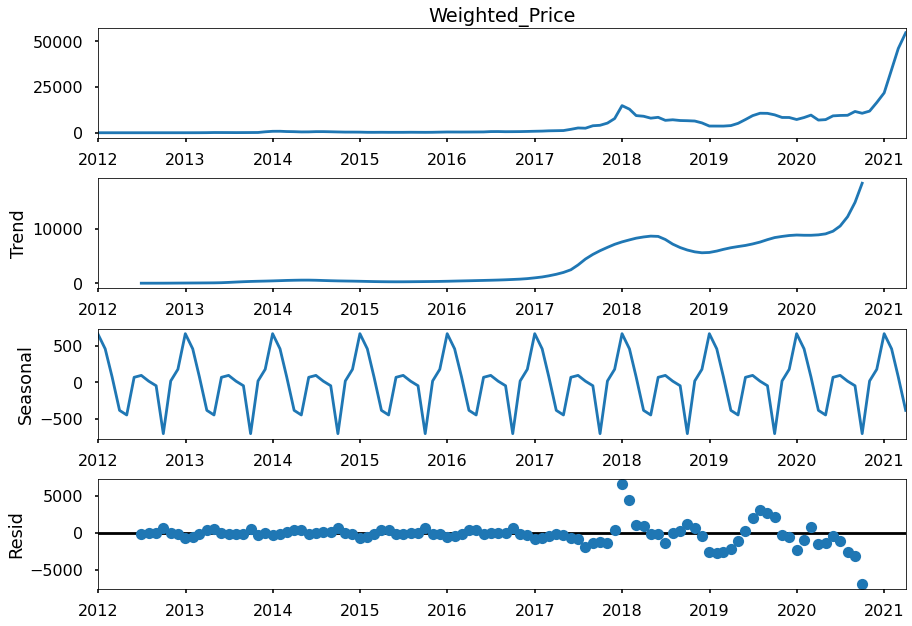

In [19]:
plt.figure(figsize=[15,7])
sm.tsa.seasonal_decompose(df_month.Weighted_Price).plot()
print("Dickey–Fuller test: p=%f" % sm.tsa.stattools.adfuller(df_month.Weighted_Price)[1])
plt.show()

The series are not stationary.

## Box-Cox Transformations

In [20]:
# Box-Cox Transformations
df_month['Weighted_Price_box'], lmbda = stats.boxcox(df_month.Weighted_Price)
print("Dickey–Fuller test: p=%f" % sm.tsa.stattools.adfuller(df_month.Weighted_Price)[1])

Dickey–Fuller test: p=0.998863


The series are not stationary.

## Seasonal differentiation

In [21]:
# Seasonal differentiation
df_month['prices_box_diff'] = df_month.Weighted_Price_box - df_month.Weighted_Price_box.shift(12)
print("Dickey–Fuller test: p=%f" % sm.tsa.stattools.adfuller(df_month.prices_box_diff[12:])[1])

Dickey–Fuller test: p=0.444282


The series are not stationary.

## Regular differentiation

Dickey–Fuller test: p=0.000024


<Figure size 1080x504 with 0 Axes>

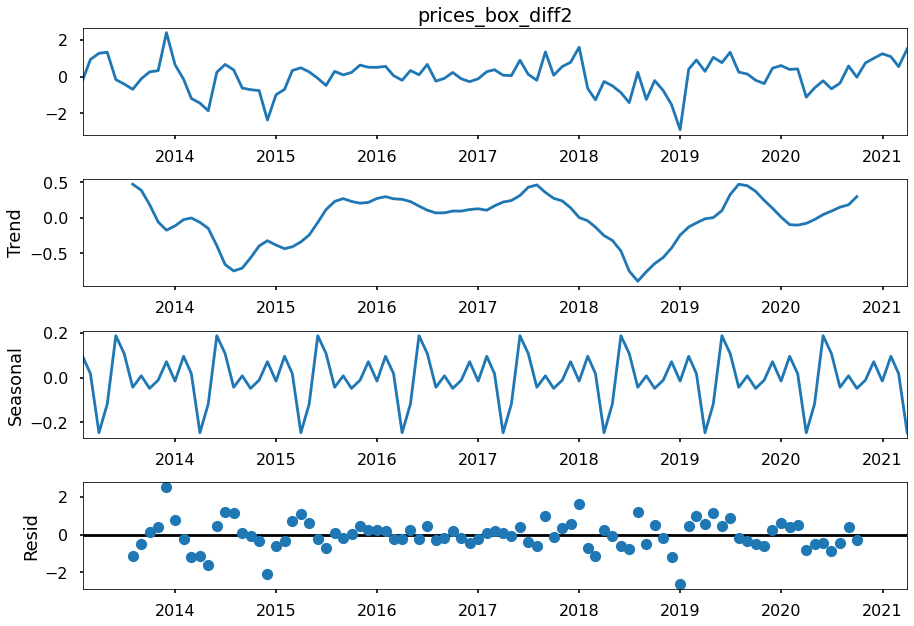

In [22]:
# Regular differentiation
df_month['prices_box_diff2'] = df_month.prices_box_diff - df_month.prices_box_diff.shift(1)
plt.figure(figsize=(15,7))

# STL-decomposition
sm.tsa.seasonal_decompose(df_month.prices_box_diff2[13:]).plot()   
print("Dickey–Fuller test: p=%f" % sm.tsa.stattools.adfuller(df_month.prices_box_diff2[13:])[1])

plt.show()

The series are stationary.

---
## Step 1 & 2: Time Series Pipeline (PyCaret)

Automated time series pipeline with PyCaret:
- `setup()` → preprocessing & configuration
- `compare_models()` → model selection
- `finalize_model()` → train on full data


In [ ]:
from pycaret.time_series import *

ts_setup = setup(data=df, target='Close', fh=12, session_id=42, verbose=False)

# Compare models and select best
best_model = compare_models()

# Display comparison results
print(best_model)


In [ ]:
# Plot forecast
plot_model(best_model, plot='forecast')


In [ ]:
# Finalize the model
final_model = finalize_model(best_model)

# Make predictions
predictions = predict_model(final_model)
print(predictions)